# Correlations!

It should be obvious what we are going to do next.  

This is "easy". Add correlations to the graphs.

We are going to go back and use linregress to look for correlations between arsenic and other parameters.  Then we will plot them.....  


This is the hardest stuff we have done.  But we are taking two classes. Take your time and try to understand each step.  I have all the answers at the end.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

Get the data in!!!

In [2]:
df=pd.read_csv('well_data.csv')

A few notes. Again, pay attention to the details.  Take it slow.  Also, today I am using x again for now (I still migh change names later.  Don't let that trip you up.  You control the names!  First lets plot arsenic versus iron

Text(0, 0.5, 'Fe')

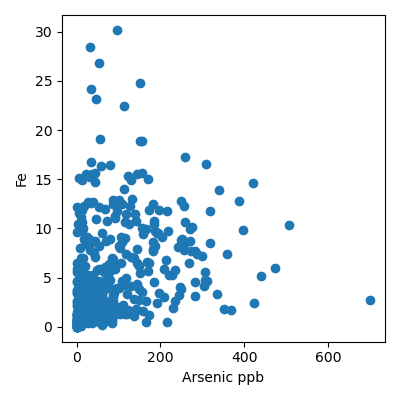

In [4]:
fig,ax=plt.subplots(layout='tight')
fig.set_size_inches(4,4)  #I made it smaller for printing.  You can skip this line
ax.scatter(df.As,df.Fe)
ax.set_xlabel('Arsenic ppb')
ax.set_ylabel('Fe')


We will want to automate things today. So lets try and use variables for x and y or independent and dependent variables.

Text(0, 0.5, 'Fe')

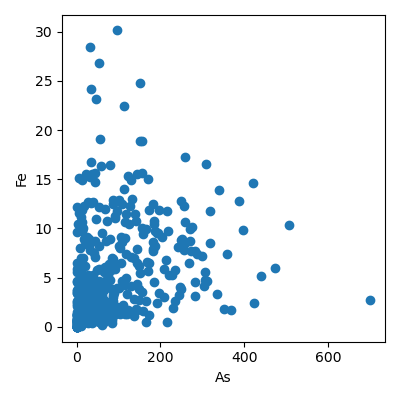

In [5]:
x='As'
y='Fe'

fig,ax=plt.subplots(layout='tight')
fig.set_size_inches(4,4)
ax.scatter(df[x],df[y])
ax.set_xlabel(x)
ax.set_ylabel(y)

remember you can save figures. 

fig.savefig('Name_of_figure.jpg',dpi=200,bbox_inches='tight')


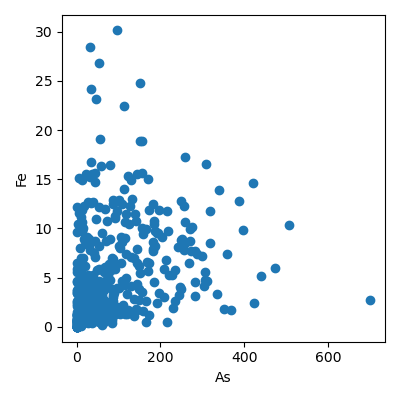

In [6]:
x='As'
y='Fe'

fig,ax=plt.subplots(layout='tight')
fig.set_size_inches(4,4)
ax.scatter(df[x],df[y])
ax.set_xlabel(x)
ax.set_ylabel(y)

fig.savefig('my_first_figure.jpg',dpi=200,bbox_inches='tight')

Remember you make up the names.  So instead of x and y you could do independent and dependent variable.

Text(0, 0.5, 'Fe')

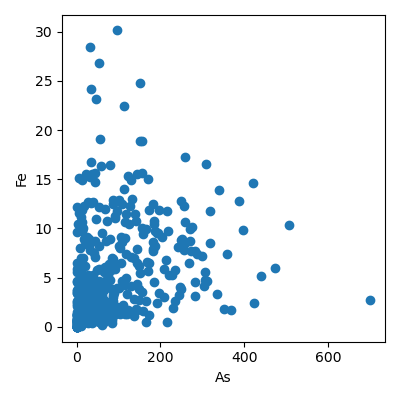

In [7]:
ind='As'
dep='Fe'

fig,ax=plt.subplots(layout='tight')
fig.set_size_inches(4,4)
ax.scatter(df[ind],df[dep])
ax.set_xlabel(ind)
ax.set_ylabel(dep)

For later on we will want to make sure we are only plotting continuous data.  So before we plot we might want to chack and make sure the y values are a float 

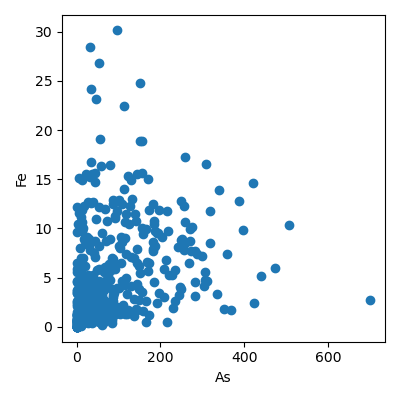

In [8]:
x='As'
y='Fe'

fig,ax=plt.subplots(layout='tight')
fig.set_size_inches(4,4)

if df[y].dtype==float:
    ax.scatter(df[x],df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)


Now lets add linregress to see the correlations.  This has some tricks.  So we will do it seperately and pull it together.  We want stats.linregess(x,y).  Unfortunately this gives us NaN or not a number.  

In [9]:
x='As'
y='Fe'

stats.linregress(df[x],df[y])

LinregressResult(slope=nan, intercept=nan, rvalue=nan, pvalue=nan, stderr=nan, intercept_stderr=nan)

These NaN's are becuase stats uses all the data.  pandas screens out the NaN's when it does math.  So we need to get rid of them.  There is a function dropna().  But we need to drop from when either one or both have an NaN.  I think it is easier to make a new dataframe for this.  So take just As and i and put them into a new pandas dataframe called temp.

In [10]:
temp=df[[x,y]]

In [11]:
print (temp.head())

         As        Fe
0       NaN       NaN
1       NaN       NaN
2       NaN       NaN
3  78.97747  1.260031
4       NaN       NaN


But we still have nan's.  lets make it with Nan dropped.  

In [12]:
temp=df[[x,y]].dropna()

In [13]:
print (temp.head())

           As         Fe
3   78.977470   1.260031
6   28.070949   1.843156
8   96.885674  11.740445
9   80.627214   8.923465
11  77.006865   6.349396


Now try linregress again but on the new temp! Think about how to reference it! 

In [14]:
x='As'
y='Fe'
temp=df[[x,y]].dropna()
stats.linregress(temp[x],temp[y])

LinregressResult(slope=0.01299689964334686, intercept=4.390525620904394, rvalue=0.2560418095014199, pvalue=1.6310638519922982e-07, stderr=0.0024382468890464413, intercept_stderr=0.33008481223672714)

or we can cheat and just pass temp

In [15]:
x='As'
y='Fe'
temp=df[[x,y]].dropna()
stats.linregress(temp)

LinregressResult(slope=0.01299689964334686, intercept=4.390525620904394, rvalue=0.2560418095014199, pvalue=1.6310638519922982e-07, stderr=0.0024382468890464413, intercept_stderr=0.33008481223672714)

### Confession.  
I used to always make a temp array to do linregress.  I think I like doing it one fell swoop to clean up the code.  You can dropna and pass your variables.

In [16]:
x='As'
y='Fe'

stats.linregress(df[[x,y]].dropna())

LinregressResult(slope=0.01299689964334686, intercept=4.390525620904394, rvalue=0.2560418095014199, pvalue=1.6310638519922982e-07, stderr=0.0024382468890464413, intercept_stderr=0.33008481223672714)

### This is review for how to make your text box.  


Now we are getting close.  Look up help to remember what all the output is.  Then we can write a caption using fancy print formatting.  
- You have done this a few times.  But this is a review. 
- set results to linregress and you will get a list. 
- Then you can make a textstr 
- print textstr explaining the results.  
- If you type $r^2$ (This is dollar signs around r^2 to make the math) at some point later on the graphs we will get a real r-squared.  

Here is the linregress link to remind you of the output.  http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

The nice thing with Python 3 is it now gives the names in the output!  Oh life is so easy!

remember to get the results you can do results[0] or results.slope to get the same answer or set it equal to m,b,r_value,p_value=....

m=0.013
b=4.391
$r^2$=0.066
p=0.000


Now lets print our one graph with the data.  For these look at our favorite recipes 
http://matplotlib.org/users/recipes.html
and scroll all the way to the bottom.  This is a reminder of what you need to do.  

1.  Make your text string
2.  Make props to give you properties for the box.
3.  pass ax.text and place the box.  

Use your graph from above and add this stuff in.   Plus bring in linregress text string into the same program.  You should almost have all the parts! 

Fe


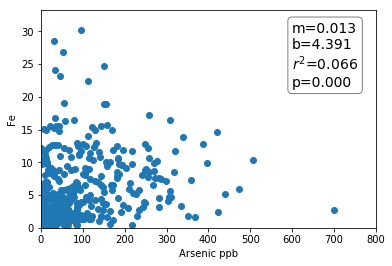

Now we just need to add the best fit line.  You have the m and b from linregress. 

Remember we talked about what to use for x_fit.  I found the answer to what works best.  Rememebr I said you could use
1.  your x-values
1.  the min and max of the x values
1.  Random numbers you make up.

I found out why min and max of the x values works the best.  If you use all the x-values it adds a lot of points to the line and then the line looks funny.  If you use the min and max of the x-values the line comes out nice.  I would do x_fit=np.array([df[x].min() and df[x].max()). 



Fe


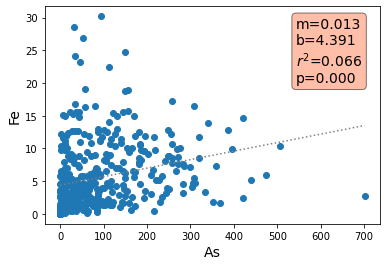

The next step is to loop over each column and print the data type.  Pandas is crazy.  If you put the dataframe in a for loop it goes through the columns automatically.  



In [17]:
for col in df:
    print(col)

Well_ID
Lat
Lon
Depth
Drink
Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


I called it 

for col in df:

This way I thought col was short for columns.  but we could call it anything. literally

In [18]:
for anything in df:
    print(anything)

Well_ID
Lat
Lon
Depth
Drink
Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


But we only want to loop over the elements.  So we should start at Si.  so can for loop from that column onward.  From our notes from last class I know of at lease two ways to choose all columns from Si onward

df.loc[:,'Si':]

df.iloc[:,5:]

In [19]:
for col in df.iloc[:,5:]:
    print(col)

Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


Now make a new subplot for each of those when you go through the for loop.  

I made these really small to save paper.  Take out the set_size_inches since you won't print

Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


/var/folders/dw/0b9k7c_s7nj6fspmx6n2gbk40000gp/T/ipykernel_29940/1243767435.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax=plt.subplots()


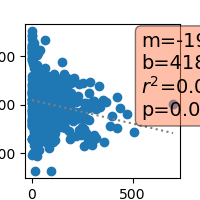

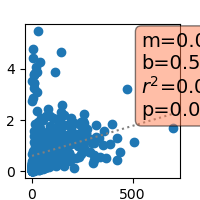

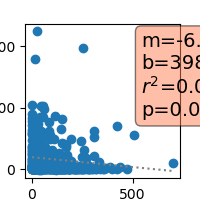

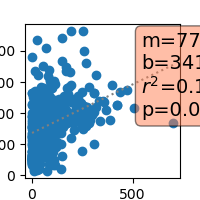

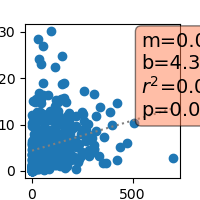

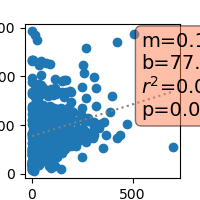

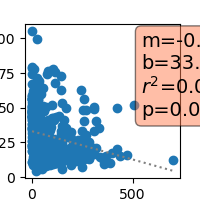

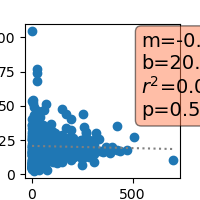

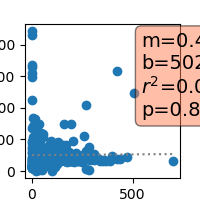

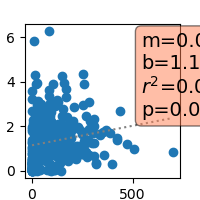

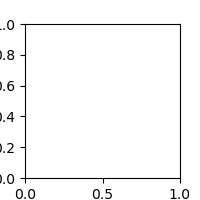

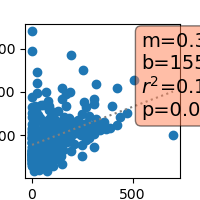

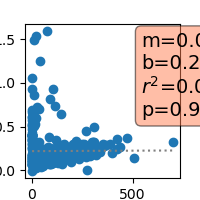

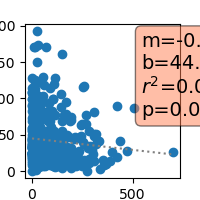

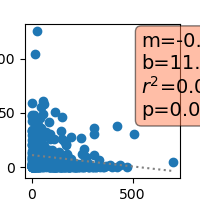

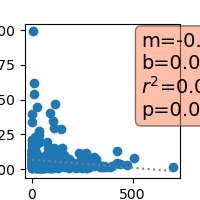

In [20]:
props=dict(boxstyle='round',facecolor='coral',alpha=0.5)

for col in df.iloc[:,5:]:
    fig,ax=plt.subplots()
    fig.set_size_inches(2,2)

    x='As'
    y=col

    print (y)

    if x!=y:
        ax.scatter(df[x],df[y])
        ax.set_xlabel(x,fontsize=14)
        ax.set_ylabel(y,fontsize=14)

        results=stats.linregress(df[[x,y]].dropna())

        textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                        format(results.slope,results.intercept\
                              ,results.rvalue**2,results.pvalue)

        x_fit=np.array([df[x].min(),df[x].max()])
        ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

        ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
                ,verticalalignment='top',bbox=props)

### You know this pdf part by now!

I don't like all the plots in python.  I want one pdf with all the graphs to share.  Let's do it. 

Make a pdf file with all the graphs.
* We could make lots of jpg files.  Instead we are going to make a multipage pdf.  Just like last time.  Here is the method again 
* open a pdf file.  pp = PdfPages('As-corr.pdf')
* pp is the pdf file.  You can now write graphs to it.  
* now after each figure call pp.savfig()
* This saves each figure to a new page in the pdf
* only call subplots once and that is before the loop
* then in the loop after you savefig you can ax.cla()
* This clears the axes for the next time through the loop.
* Then one last critical part.  Once done with the loop and outside the loop you need to close the pdf file. pp.close()
* If you don't close it the file stays open in your computer memory for ever and is untouchable.  Causes headaches.  If this happens you need to make a new file name.
* Also I made it so Arsenic won't plot against Arsenic to make things cleaner

Good luck!!!



Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


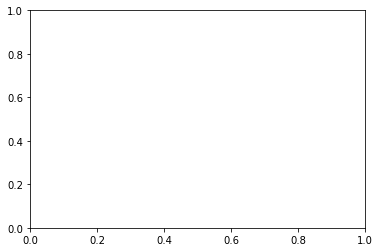

### Great Job.
I just taught you how to p-hack your data.  p-hacking is wrong.  I think Taylor Swift said it correctly.  

They say I did something bad

Then why's it feel so good?


p-hacking is bad but it is what people do! https://bitesizebio.com/31497/guilty-p-hacking/   So as long as you are concious of what you are doing it is sort of ok. You should really start with a hypothesis and then look for correlations.  But it is also alright to explore the data this way.  Just be cognizant of the weaknesses.

But this is great.  we have all the data.  But now we want to take the best 4 or 6 r$^2$ values and plot them on one sheet.  to get the r$^2$ values we could look through all the graphs.  or we can store them and look at them. I don't have a perfect method to do this.  I used to make a dictionary.  But now I think it is easier to make an empty DataFrame and then fill it in.  Here is what I do

1.  Use your last code but add a few lines to save and store the r$^2$ values.  
1.  Make a new empty DataFrame with pd.DataFrame() I call mine df_r2 =pd.DataFrame()
2.  add to the dataframe each time you loop through.  
2.  adding to dataframes by rows is sort of a pain.  
2.  I use .at to add to a dataframe.  you do df.at[index,'column']=value
3.  But the index will be a number of rows that we are counting.  It could be something else but that is what I use.
2.  You will need a way to count.  you can use enumerate or the length of the dataframe.  
2.  We will do these next two steps later.
4.  finally sort the pandas dataframe.
5.  print out the results.  

0 Si
1 P
2 S
3 Ca
4 Fe
5 Ba
6 Na
7 Mg
8 K
9 Mn
10 As
11 Sr
12 F
13 Cl
14 SO4
15 Br


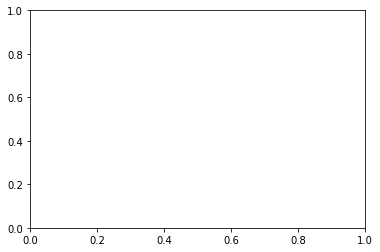

### here is the r$^2$!

In [25]:
df_r2

,r2,name
0,0.037977,Si
1,0.069488,P
2,0.014789,S
3,0.154148,Ca
4,0.065557,Fe
5,0.059968,Ba
6,0.053342,Na
7,0.000824,Mg
8,0.000090,K
9,0.032770,Mn


### Now we need to sort the dataframe.
Here is the link.  https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.sort_values.html
A key thing is the inplace keyword you have not seen before.  inplace tells it to sort and keep it.  Otherwise it just sorts and shows you and puts it back.  You could also set it to itself.  So you have two options
* df_r2.sort_values(by='r2',ascending=False,inplace=True)
* df_r2=df_r2.sort_values(by='r2',ascending=False)

In [26]:
df_r2.sort_values(by='r2',ascending=False,inplace=True)

Python doesn't like sorting dictionaries.  So that is why I like using a dataframe. Plus once you learn the .at trick it is easy to make a dataframe.  I will set the rows to an index and make the column name rsq.  Here is a problem.  Pandas used to have a function sort. It no longer has it and now it is sort_values

In [27]:
print (df_r2)

          r2 name
11  0.155595   Sr
3   0.154148   Ca
1   0.069488    P
4   0.065557   Fe
5   0.059968   Ba
6   0.053342   Na
0   0.037977   Si
9   0.032770   Mn
14  0.021915  SO4
15  0.018130   Br
2   0.014789    S
13  0.009093   Cl
7   0.000824   Mg
8   0.000090    K
12  0.000030    F


## A mistake from last year was to leave the adding to the df_r2 dataframe in later cells. This messed us up because it kept on getting added to.  

### This is our Goal

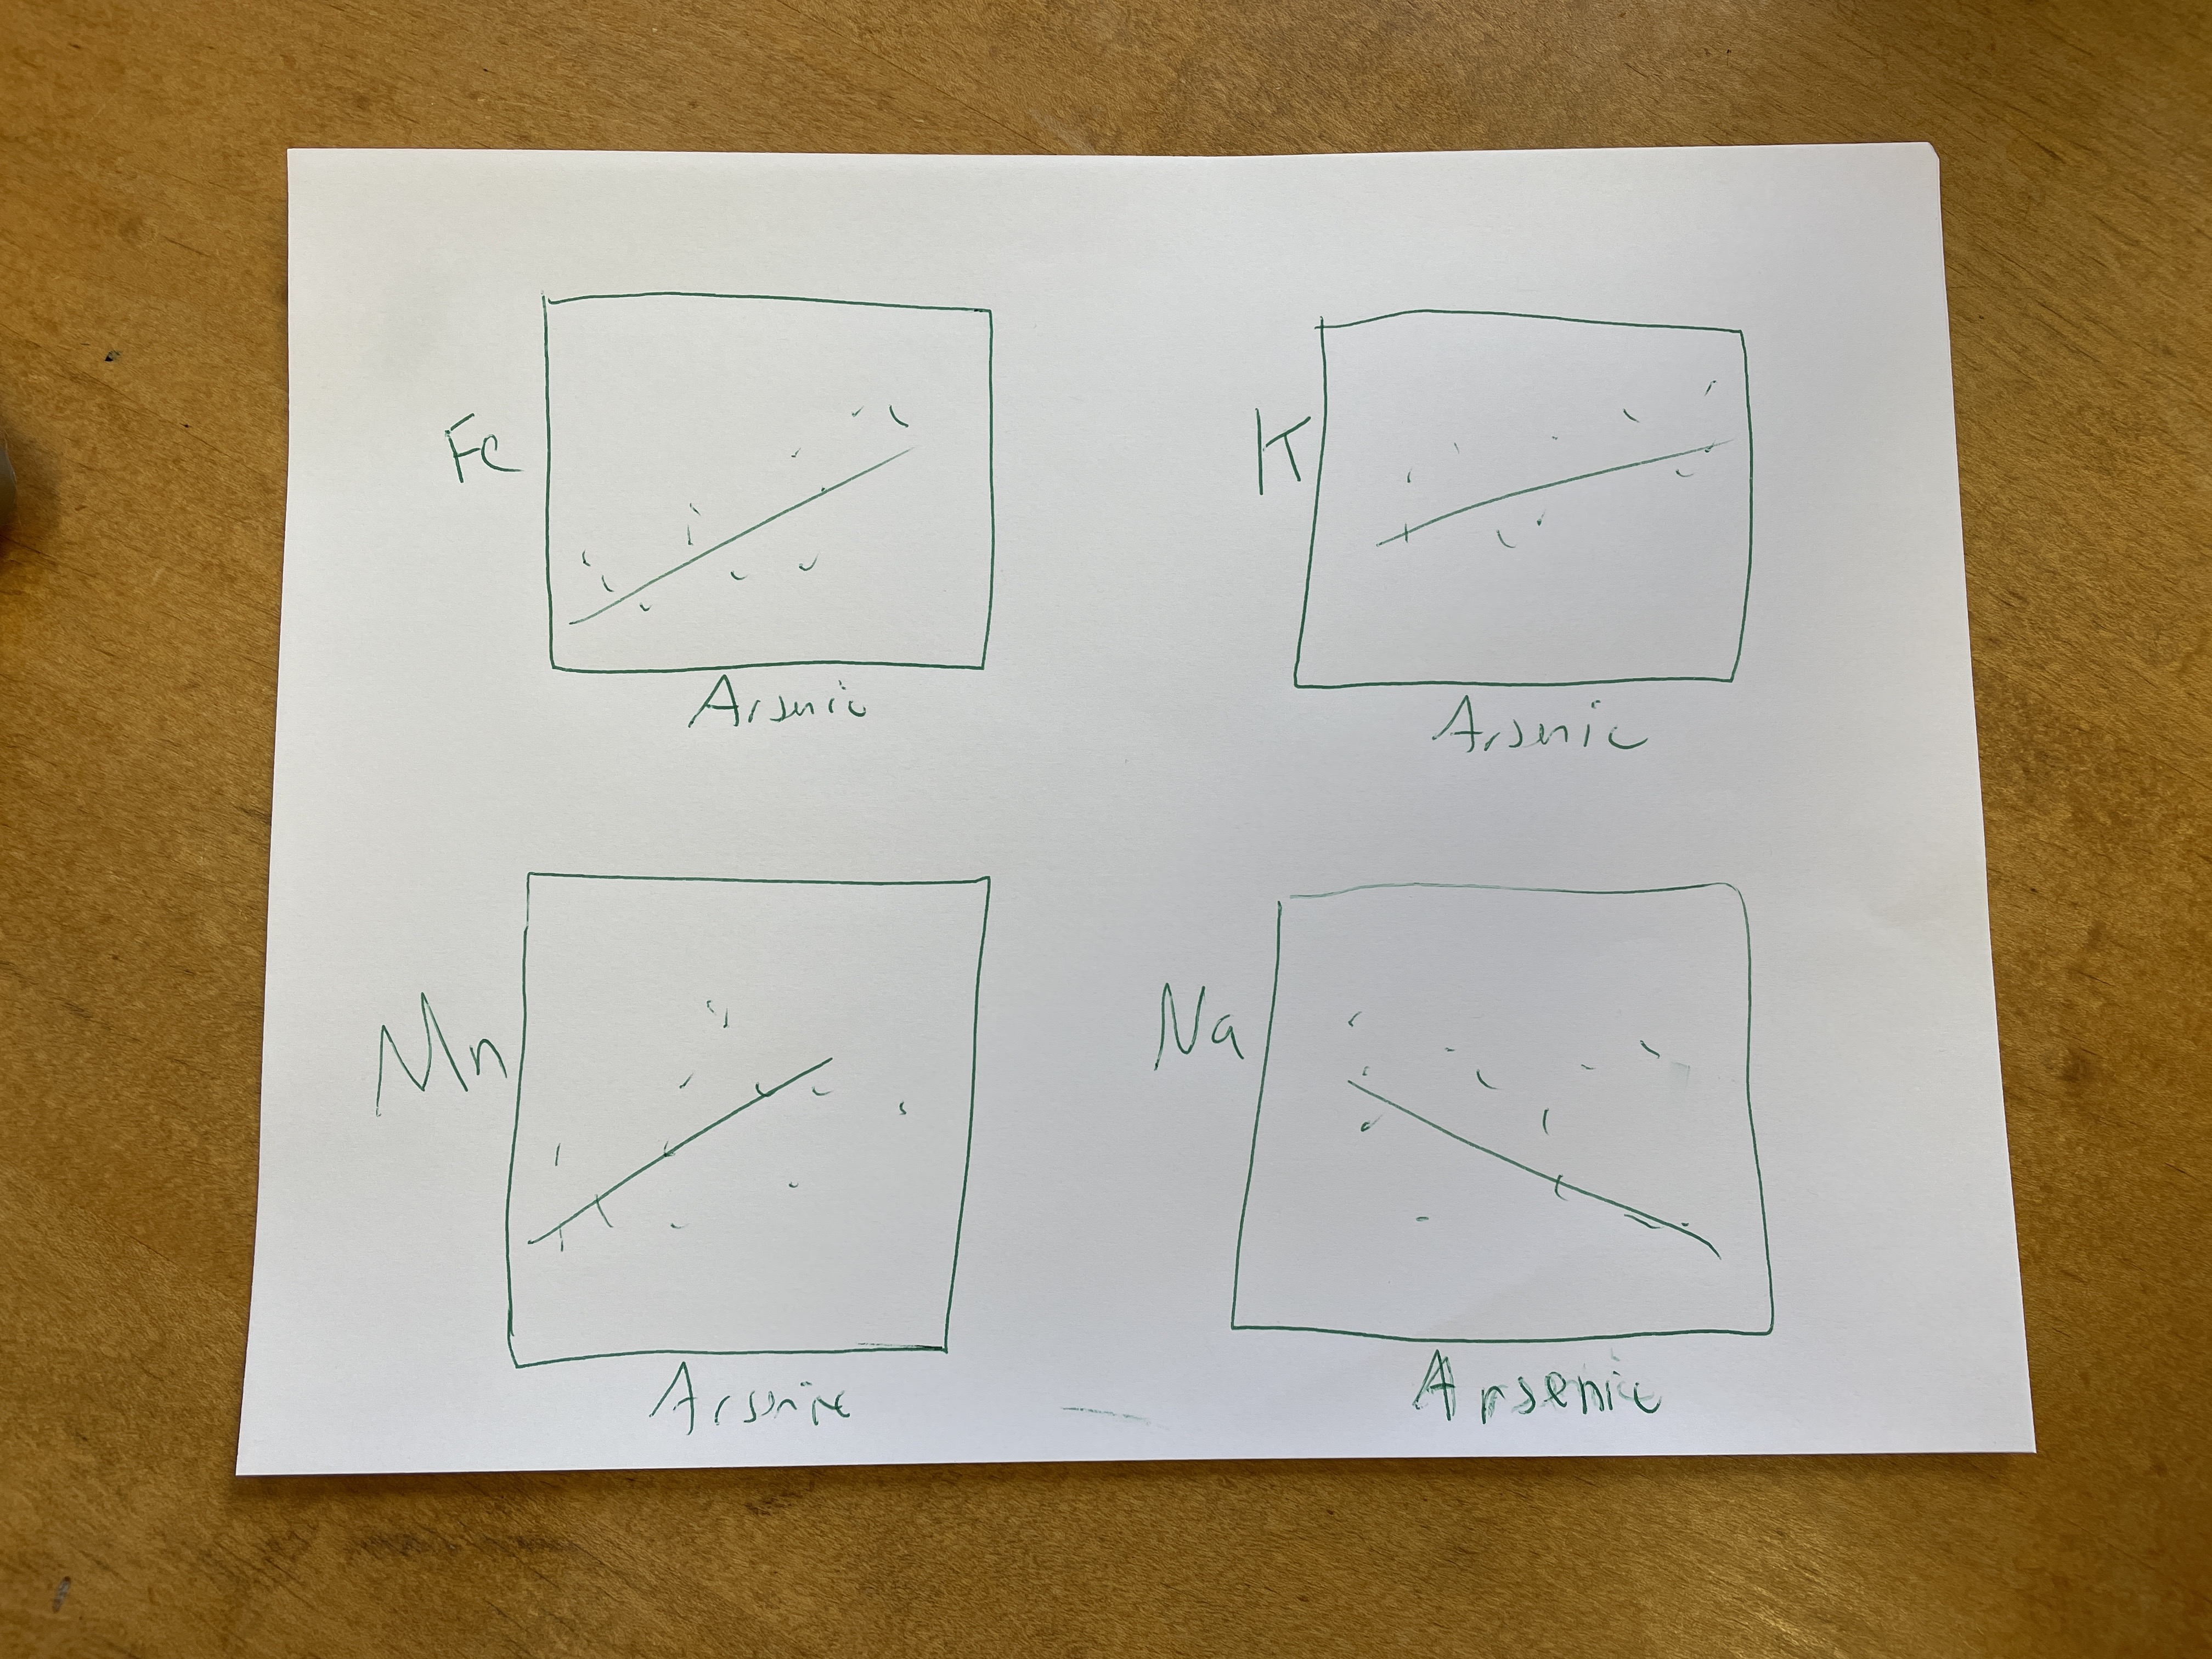

In [28]:
from IPython.display import Image
Image(filename='Figure-schematic.JPG',width=500)

Now lets put our top 4 correlations onto one page!  I will walk you through it.  Grab your plot from above and strip out the file information and the for loop and the .at.  It should just be a plot of x=arsenic versus y.  You can set y='Fe'

Text(0.75, 0.95, 'm=0.013\nb=4.391\n$r^2$=0.066\np=0.000')

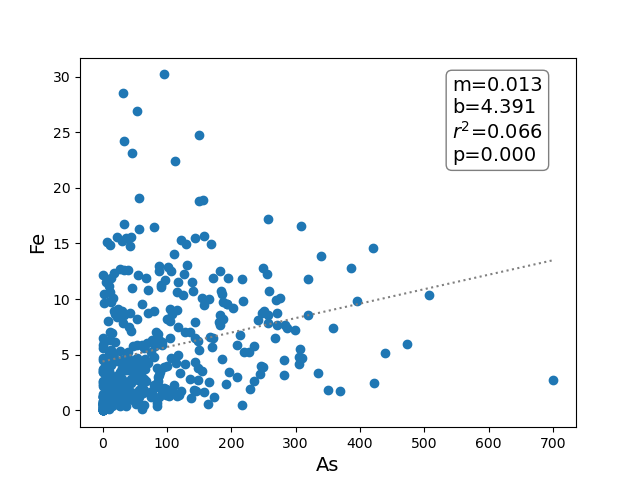

In [21]:
fig,ax=plt.subplots()
props=dict(boxstyle='round',facecolor='white',alpha=0.5)

x='As'
y='Fe'

ax.scatter(df[x],df[y])
ax.set_xlabel(x,fontsize=14)
ax.set_ylabel(y,fontsize=14)

results=stats.linregress(df[[x,y]].dropna())

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                format(results.slope,results.intercept\
                      ,results.rvalue**2,results.pvalue)

x_fit=np.array([df[x].min(),df[x].max()])
ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
        ,verticalalignment='top',bbox=props)



## Goal 

-  We want 4 graphs nicely lined up on one page to print. 
-  make the subplots 2,2 so we can show four graphs. 
-  We are going to use a for loop like last time.  
-  So lets make a list of elemsents we want to graph.  
-  Grab the top four r$^2$ elements from above.     

### First make your subplots(2,2)

You will get an error because ax is a two-d array. 
### You are going to get an error!!

AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

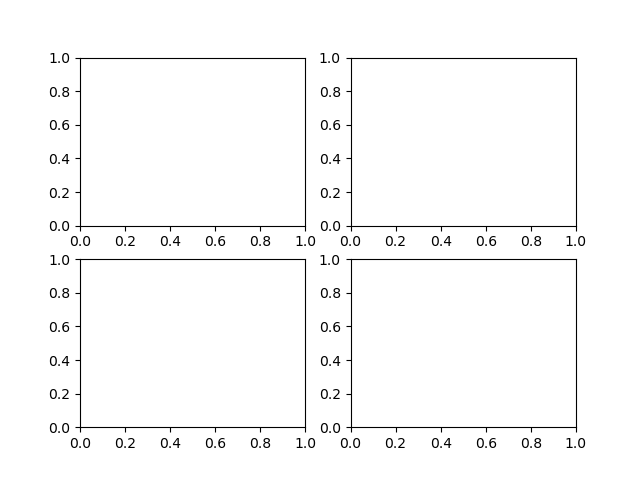

In [31]:
fig,ax=plt.subplots(2,2)

ax.scatter(df[x],df[y])
ax.set_xlabel(x,fontsize=14)
ax.set_ylabel(y,fontsize=14)

results=stats.linregress(df[[x,y]].dropna())

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                format(results.slope,results.intercept\
                      ,results.rvalue**2,results.pvalue)

x_fit=np.array([df[x].min(),df[x].max()])
ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
        ,verticalalignment='top',bbox=props)


### The problem is now your ax is a 2d array!!!!

Where you call ax after the initial value where you set it make it ax[0,0]

there are a few hidden ax calls!



Text(0.75, 0.95, 'm=0.013\nb=4.391\n$r^2$=0.066\np=0.000')

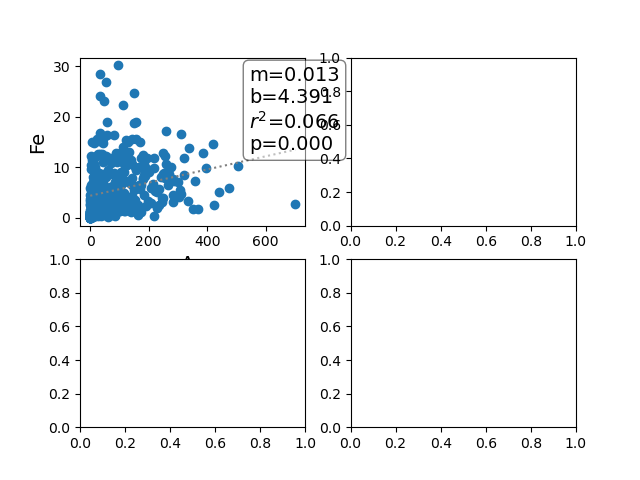

In [22]:
fig,ax=plt.subplots(2,2)

ax[0,0].scatter(df[x],df[y])
ax[0,0].set_xlabel(x,fontsize=14)
ax[0,0].set_ylabel(y,fontsize=14)

results=stats.linregress(df[[x,y]].dropna())

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                format(results.slope,results.intercept\
                      ,results.rvalue**2,results.pvalue)

x_fit=np.array([df[x].min(),df[x].max()])
ax[0,0].plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

ax[0,0].text(0.75,0.95,textstr,transform=ax[0,0].transAxes,fontsize=14\
        ,verticalalignment='top',bbox=props)

### Next step

That worked nicely. Now go back up and make graph on the next graph over!

Plus make it bigger using fig.set_size_inches(10,10)

Text(0.75, 0.95, 'm=0.013\nb=4.391\n$r^2$=0.066\np=0.000')

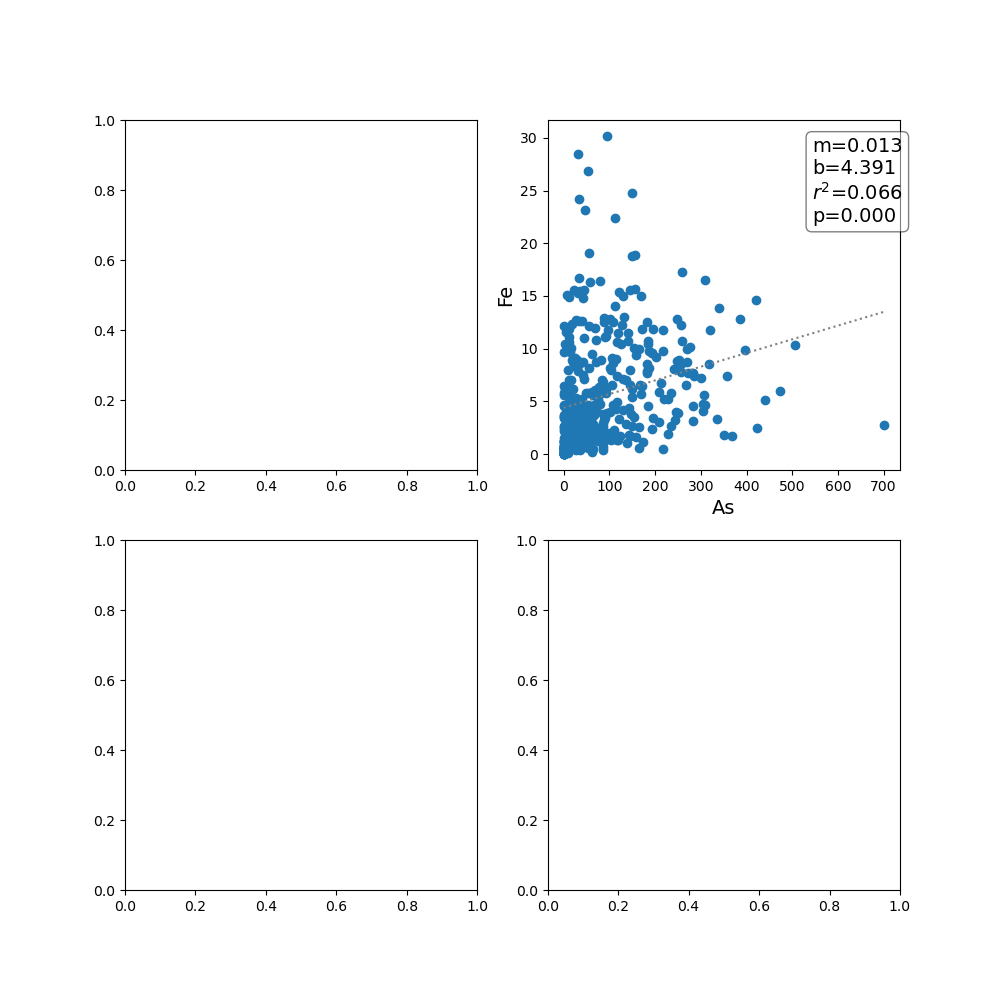

In [23]:
fig,ax=plt.subplots(2,2)

fig.set_size_inches(10,10)

ax[0,1].scatter(df[x],df[y])
ax[0,1].set_xlabel(x,fontsize=14)
ax[0,1].set_ylabel(y,fontsize=14)

results=stats.linregress(df[[x,y]].dropna())

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                format(results.slope,results.intercept\
                      ,results.rvalue**2,results.pvalue)

x_fit=np.array([df[x].min(),df[x].max()])
ax[0,1].plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

ax[0,1].text(0.75,0.95,textstr,transform=ax[0,1].transAxes,fontsize=14\
        ,verticalalignment='top',bbox=props)

### That worked nicely. 

But we have a problem.  We have our list of 4 elements we want to plot.  But we have a 2x2 matrix to put them into when using ax.

#### confusing!!!!

use the script below to see how the numbering works

Change the nrows and ncols and see what you get!!!!

copy the script.  Change nrows and ncols and see what happens

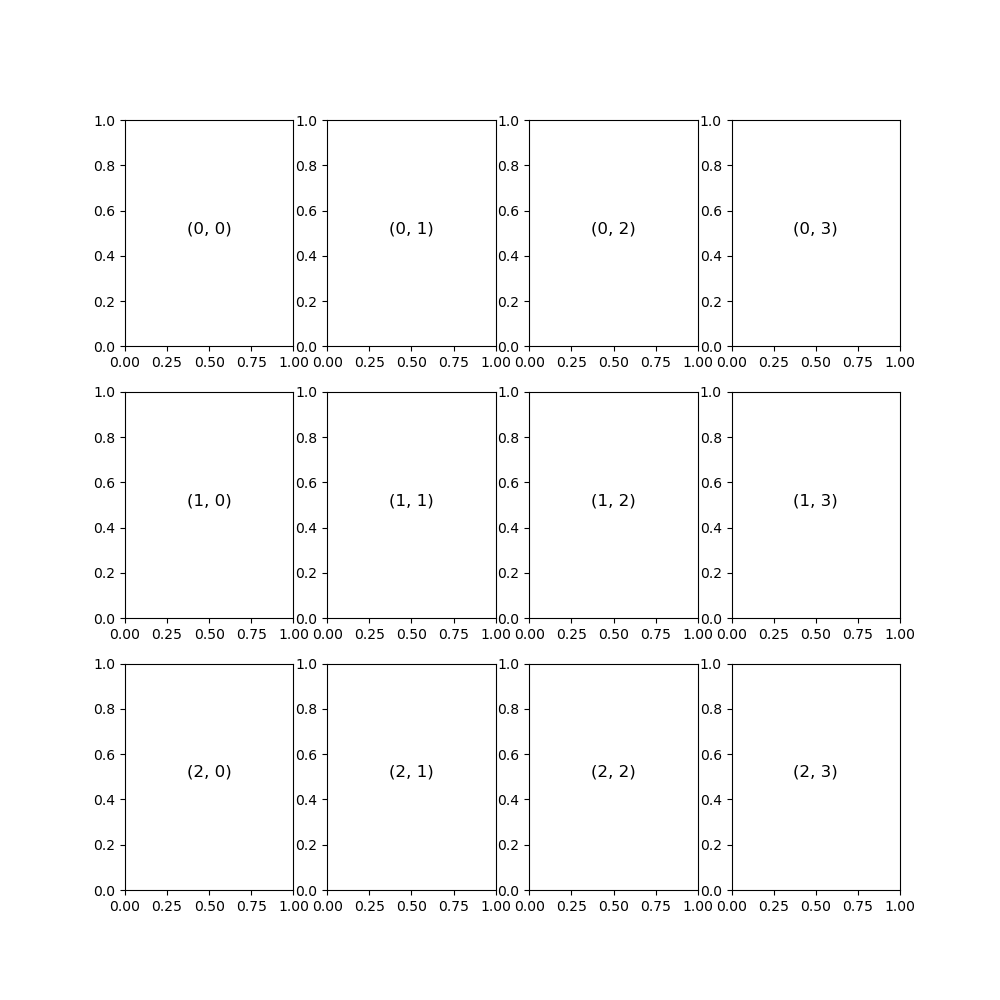

In [34]:
nrows=3
ncols=4

fig,ax=plt.subplots(nrows,ncols)
fig.set_size_inches(10,10)
for i in np.arange(nrows):
    for j in np.arange(ncols):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=12, ha='center')

### Follow me.
this is the hard part.  We have a list of elements. we want plotted.  It is a one-dimensional list with a length.  But we want to put them on a two dimensional array of graphs.  To continue our example above 
-  we are going to use np.ravel https://docs.scipy.org/doc/numpy/reference/generated/numpy.ravel.html
-  this flattens an array. It takes a 2d array and makes it into a 1d array 
-  We can turn ax into a 1d array.

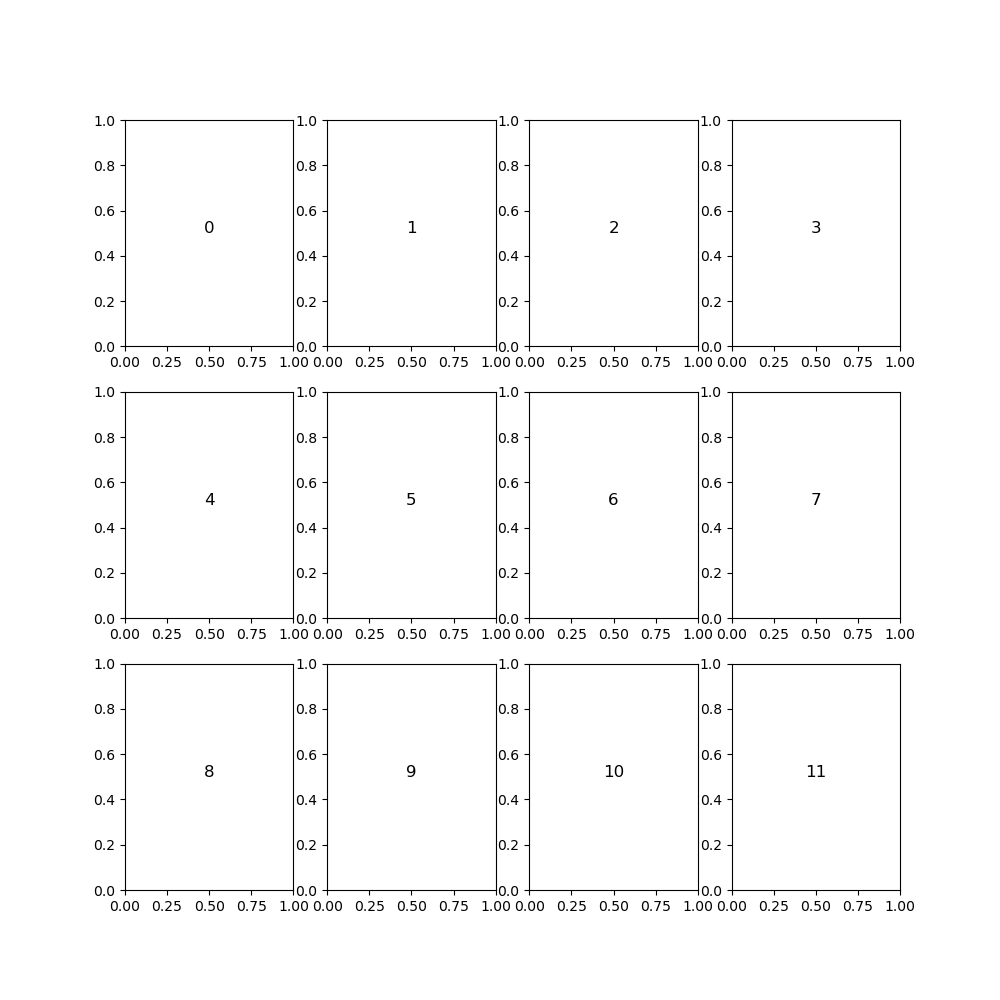

In [35]:
nrows=3
ncols=4
ngraphs=nrows*ncols
fig,ax2d=plt.subplots(nrows,ncols)
fig.set_size_inches(10,10)
ax=np.ravel(ax2d)  

for count in np.arange(ngraphs):
    ax[count].text(0.5, 0.5, str((count)),
                      fontsize=12, ha='center')

### Did you see that? Are you still with me?

Remember that we had our list of elements we wanted to plot?  

#### Flashback

Do you remmeber I said we might want to count and give the value of an array?  

Here is my quote from the notes.  

Python has a simple trick to count through a list and give you the list.  It may not make sense now but it will later in the semester!  PAY ATTENTION TO THIS!

and I gave this example



In [34]:
mystrlist=['env','chem','bio','psych']
for count,mystr in enumerate(mystrlist):
    print (count,mystr)

0 env
1 chem
2 bio
3 psych


0 Sr
1 Ca
2 P
3 Fe


Lets automate it.  

* make a new parameter called el_to_plot for elements to plot
* for now set to 4.  
* now do an enumerate loop to print the top 4 elements
* then switch to 6


0 Sr
1 Ca
2 P
3 Fe


### Can we get these on a graph.  
-  Grab the code from above to alter.
-  Lets start by just printing the names.  
-  add the el_to_plot=4
-  set your nrows.  I chose 2.
- 
-  set your ncols=el_to_plot/nrows.  
- If you get an error you need to make sure ncols in an int by ncols=int(el_to_plot/nrows). 
-  Use enumerate for your for loop like above going over the top r2 values.
-  print the number and element on each graph
- remember you can just add things to print where it says str((count)) by adding in there.  for example str((count,el))

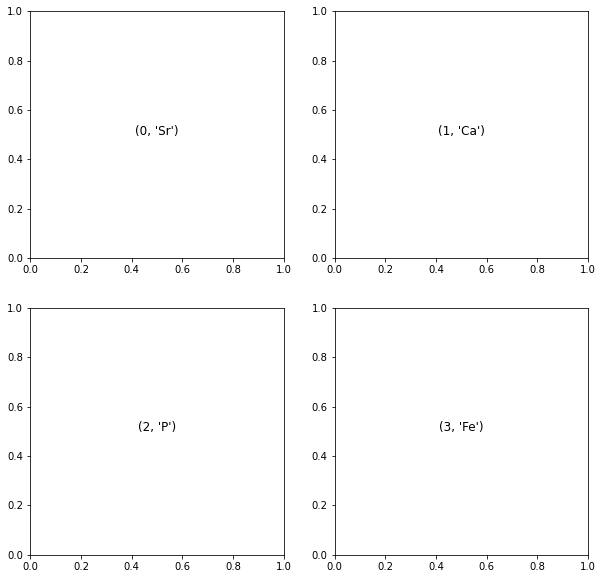

Now go back up and add two more elements to your elems array and see if the graphs update.

### Now you are ready!!!! Can you make these four plots???

If your plots get too scrunched you can add this line after turning on the fig,ax to change whitespace and make it prettier.

A note on a function you might forget is how to get the spacing between graphs to look good. You might not remember that during the arsenic versus depth graphs I needed to add whitespace between the graphs to make them look good. I used this fucntion


fig.subplots_adjust(wspace=0.3)

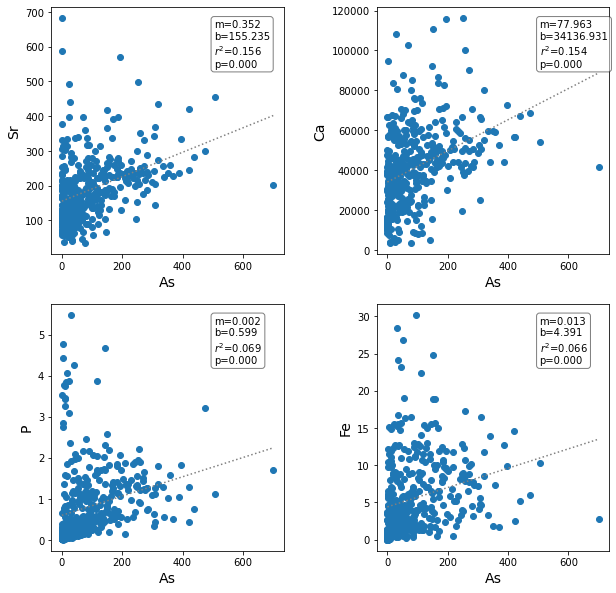

### That is beautiful!  

We are close to making this stand alone. i think we have removed most of the the hardwires.
-  Make a filename str to use to save the figure.  I added together the x and +'correlations.jpg'
-  Save to a file fig.savefig(filename)
-  Then change x to 'Mn' and see if it works.  

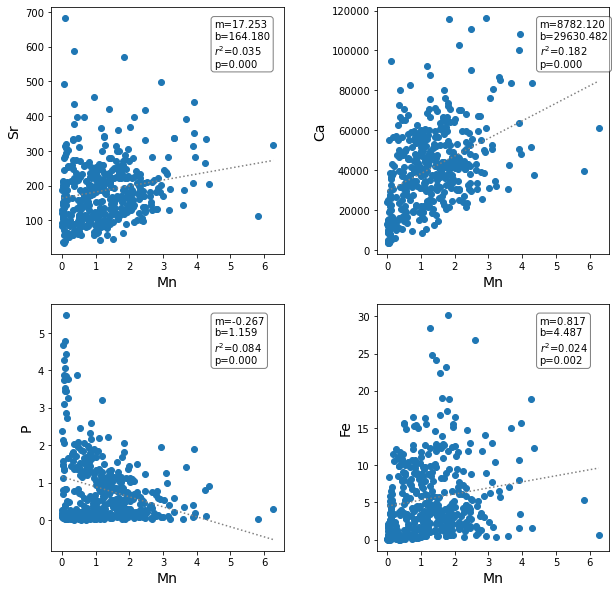

### Can we do six plots?

-  we should be able to just add two more elements to num_elements!
-  plus I added nice letters to each graph to make nice figure captions
-  you add the letters the same way you add text. 
-  I use the ord function https://docs.python.org/2/library/functions.html#ord and the chr function. https://docs.python.org/2/library/functions.html#chr
-  ord converts a string to the ASCII int and then I add i to it and convert it back with chr

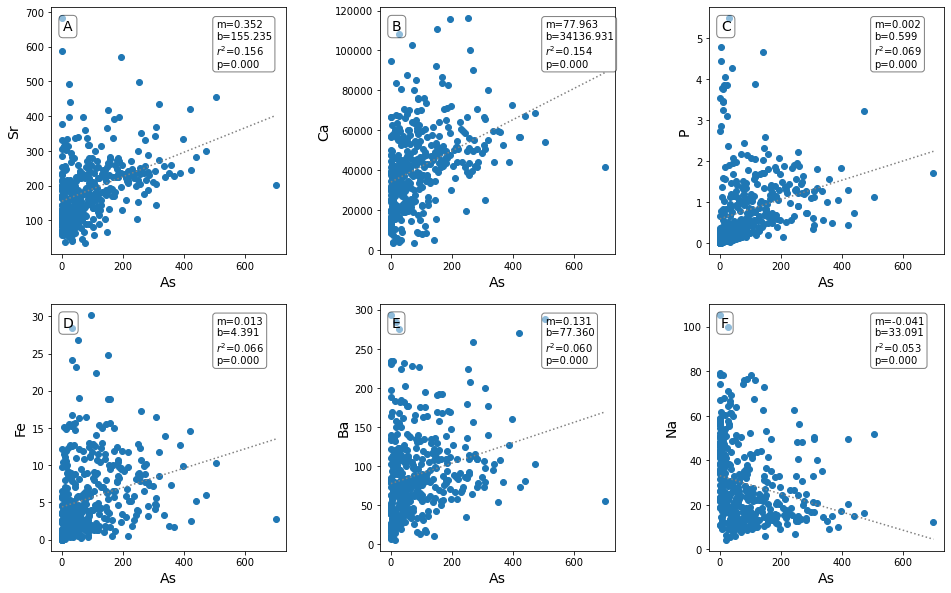

#### Now you should be able to change number or rows and elements to plots and make a nice plot

### This may not be a good thing.  But you can now officially p-hack and make as many plots of your data as you would like!!!

### For using seaborn I wanted a list of elements in order of just the values.  You might use them later

In [19]:
df_r2.sort_values(by='r2',ascending=False,inplace=True)

In [21]:
df_r2.name.values

array(['Sr', 'Ca', 'P', 'Fe', 'Ba', 'Na', 'Si', 'Mn', 'SO4', 'Br', 'S',
       'Cl', 'Mg', 'K', 'F'], dtype=object)

Also you can write your r2 values to excel.  It is easy.  just call .to_excel and give it a name with xlsx in it.

In [68]:
df_r2.to_excel('r2_class_example.xlsx')

# ANSWERS

Fe


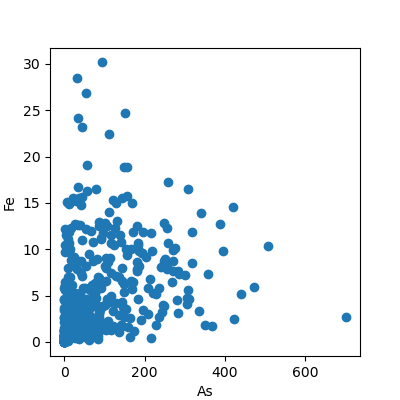

In [36]:
fig,ax=plt.subplots()
fig.set_size_inches(4,4)
x='As'
y='Fe'
print (y)
if df[y].dtype==float:
    ax.scatter(df[x],df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)

In [37]:
x='As'
y='Fe'

results=stats.linregress(df[[x,y]].dropna())
textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)
print (textstr)

m=0.013
b=4.391
$r^2$=0.066
p=0.000


Fe


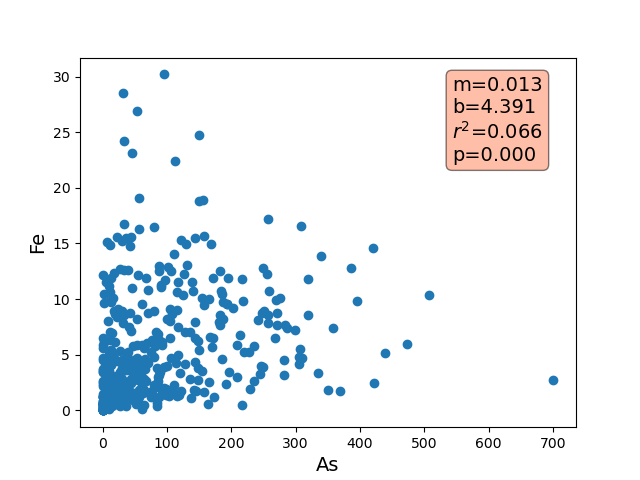

In [41]:
fig,ax=plt.subplots()

x='As'
y='Fe'

props=dict(boxstyle='round',facecolor='coral',alpha=0.5)
print (y)

if df[y].dtype==float:
    ax.scatter(df[x],df[y])
    ax.set_xlabel(x,fontsize=14)
    ax.set_ylabel(y,fontsize=14)
   
    results=stats.linregress(df[[x,y]].dropna())
    
    textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)
    
    ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
            ,verticalalignment='top',bbox=props)
    

Fe


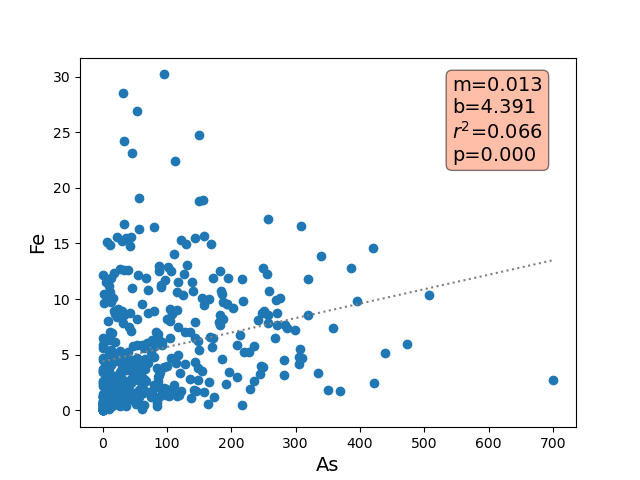

In [42]:
fig,ax=plt.subplots()

x='As'
y='Fe'

props=dict(boxstyle='round',facecolor='coral',alpha=0.5)
print (y)

if df[y].dtype==float:
    ax.scatter(df[x],df[y])
    ax.set_xlabel(x,fontsize=14)
    ax.set_ylabel(y,fontsize=14)
   
    results=stats.linregress(df[[x,y]].dropna())
    
    textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)
    
    x_fit=np.array([df[x].min(),df[x].max()])
    ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')
    
    ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
            ,verticalalignment='top',bbox=props)



### Making the pdf with the regression

Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


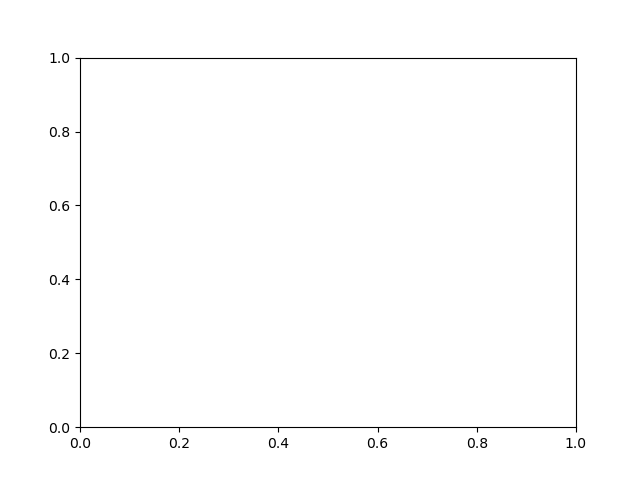

In [43]:
fig,ax=plt.subplots()
pp = PdfPages('As-corr.pdf')


for col in df.iloc[:,5:]:

    x='As'
    y=col

    props=dict(boxstyle='round',facecolor='coral',alpha=0.5)
    print (y)

    if x!=y:
        ax.scatter(df[x],df[y])
        ax.set_xlabel(x,fontsize=14)
        ax.set_ylabel(y,fontsize=14)

        results=stats.linregress(df[[x,y]].dropna())

        textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                        format(results.slope,results.intercept\
                              ,results.rvalue**2,results.pvalue)

        x_fit=np.array([df[x].min(),df[x].max()])
        ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

        ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
                ,verticalalignment='top',bbox=props)

        pp.savefig()
        ax.cla()

pp.close()

### Answer for putting r$^2$ into a dataframe useing len

Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


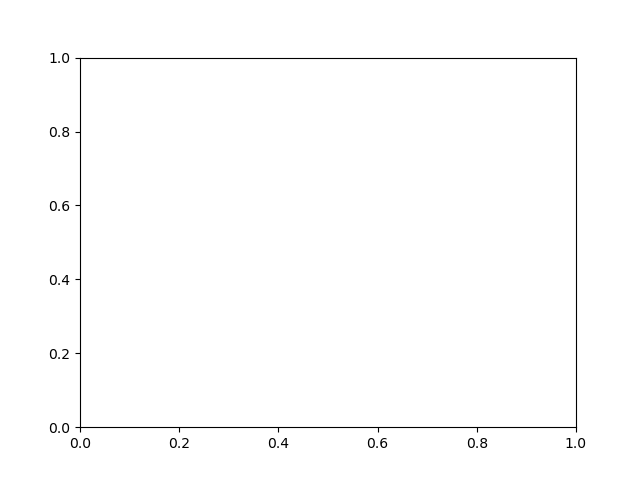

In [44]:
fig,ax=plt.subplots()
pp = PdfPages('As-corr.pdf')
df_r2=pd.DataFrame()

for col in df.iloc[:,5:]:

    x='As'
    y=col

    props=dict(boxstyle='round',facecolor='coral',alpha=0.5)
    print (y)

    if x!=y:
        ax.scatter(df[x],df[y])
        ax.set_xlabel(x,fontsize=14)
        ax.set_ylabel(y,fontsize=14)

        results=stats.linregress(df[[x,y]].dropna())

        textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                        format(results.slope,results.intercept\
                              ,results.rvalue**2,results.pvalue)
        
        index=len(df_r2)
        df_r2.at[index,'r2']=results.rvalue**2
        df_r2.at[index,'name']=y

        x_fit=np.array([df[x].min(),df[x].max()])
        ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

        ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
                ,verticalalignment='top',bbox=props)

        pp.savefig(bbox_inches='tight')
        ax.cla()

pp.close()

### Answer for r$^2$ using enumerate

Si
P
S
Ca
Fe
Ba
Na
Mg
K
Mn
As
Sr
F
Cl
SO4
Br


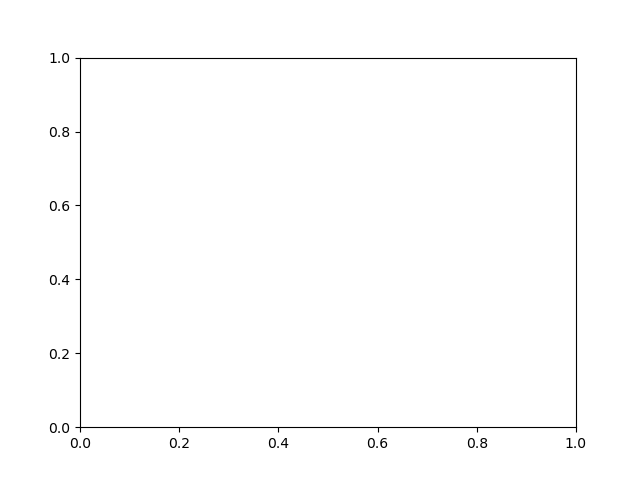

In [45]:
fig,ax=plt.subplots()
pp = PdfPages('As-corr.pdf')
df_r2=pd.DataFrame()

for count, col in enumerate(df.iloc[:,5:]):

    x='As'
    y=col

    props=dict(boxstyle='round',facecolor='coral',alpha=0.5)
    print (y)

    if x!=y:
        ax.scatter(df[x],df[y])
        ax.set_xlabel(x,fontsize=14)
        ax.set_ylabel(y,fontsize=14)

        results=stats.linregress(df[[x,y]].dropna())

        textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                        format(results.slope,results.intercept\
                              ,results.rvalue**2,results.pvalue)
        
        df_r2.at[count,'r2']=results.rvalue**2
        df_r2.at[count,'name']=y

        x_fit=np.array([df[x].min(),df[x].max()])
        ax.plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

        ax.text(0.75,0.95,textstr,transform=ax.transAxes,fontsize=14\
                ,verticalalignment='top',bbox=props)

        pp.savefig(bbox_inches='tight')
        ax.cla()

pp.close()


### to four elements

In [46]:
elements=['Sr','Ca','P','Fe']

for count,el in enumerate(elements):
    print(count,el)

0 Sr
1 Ca
2 P
3 Fe


### automate top 4

In [47]:
el_to_plot=4

for count,el in enumerate(df_r2['name'][0:el_to_plot]):
    print(count,el)

0 Si
1 P
2 S
3 Ca


### Top four elements on a graph

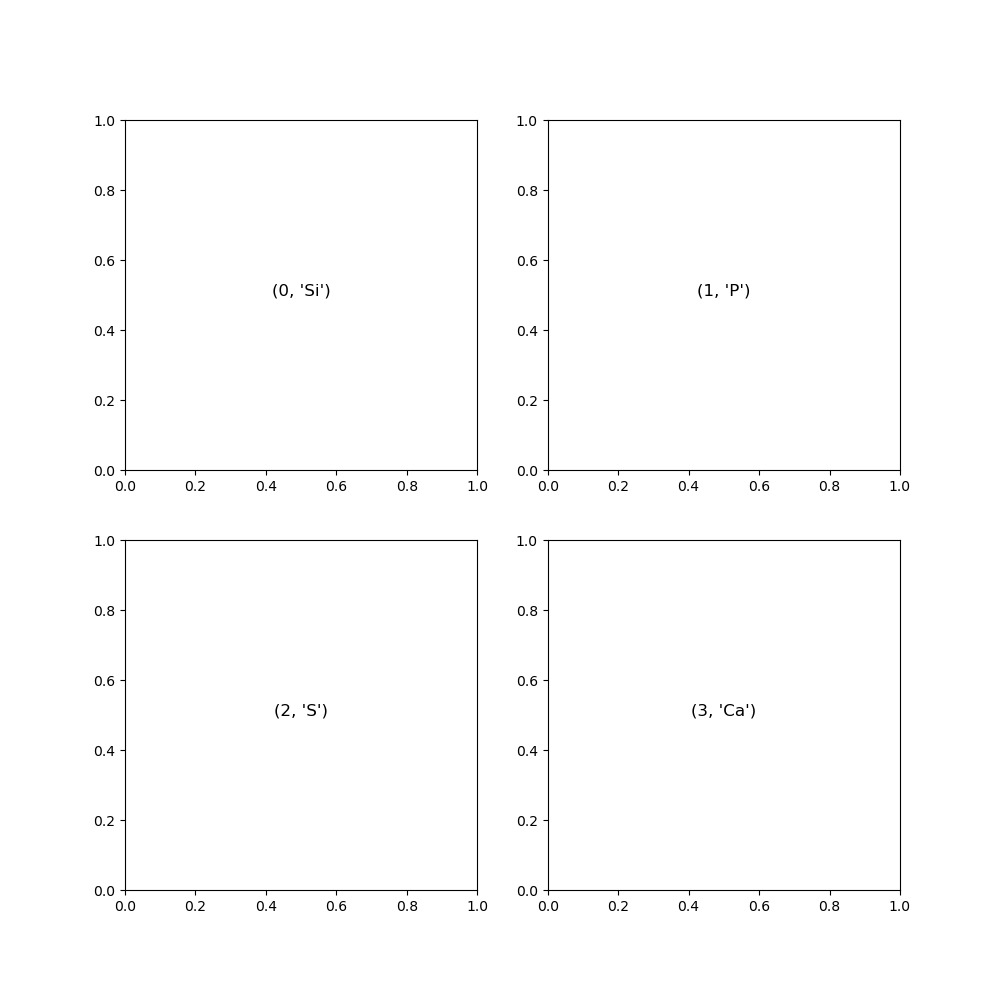

In [48]:
el_to_plot=4
nrows=2
ncols=int(el_to_plot/nrows)

fig,ax2d=plt.subplots(nrows,ncols)
fig.set_size_inches(10,10)
ax=np.ravel(ax2d)

for count,el in enumerate(df_r2['name'][0:el_to_plot]):
    ax[count].text(0.5, 0.5, str((count,el)),
                      fontsize=12, ha='center')

### Top four graphs

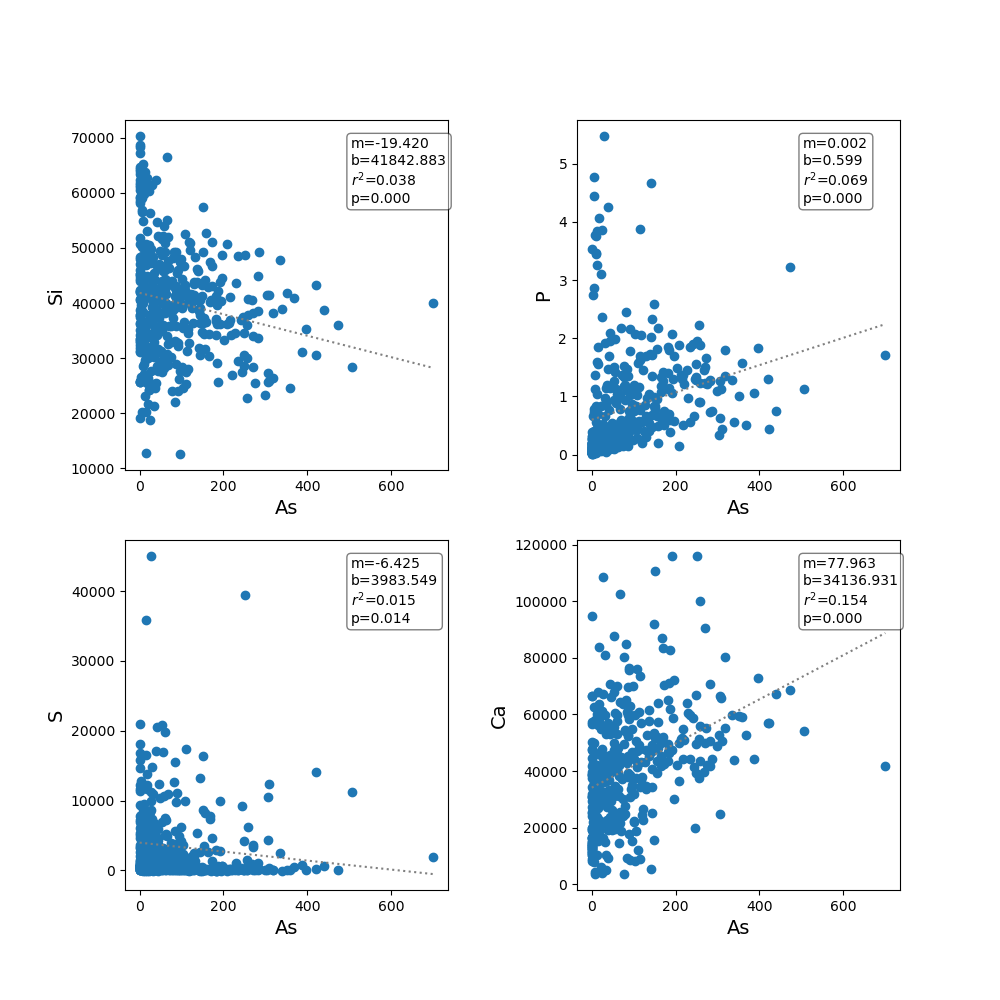

In [49]:
el_to_plot=4
nrows=2
ncols=int(el_to_plot/nrows)

fig,ax2d=plt.subplots(nrows,ncols)
fig.set_size_inches(10,10)
ax=np.ravel(ax2d)

fig.subplots_adjust(wspace=0.4)

props=dict(boxstyle='round',facecolor='white',alpha=0.5)

for count,el in enumerate(df_r2['name'][0:el_to_plot]):
    x='As'
    y=el
    ax[count].scatter(df[x],df[y])
    ax[count].set_xlabel(x,fontsize=14)
    ax[count].set_ylabel(y,fontsize=14)

    results=stats.linregress(df[[x,y]].dropna())

    textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)

    x_fit=np.array([df[x].min(),df[x].max()])
    ax[count].plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

    ax[count].text(0.7,0.95,textstr,transform=ax[count].transAxes,fontsize=10\
            ,verticalalignment='top',bbox=props)

### Cleaned up and with Mn

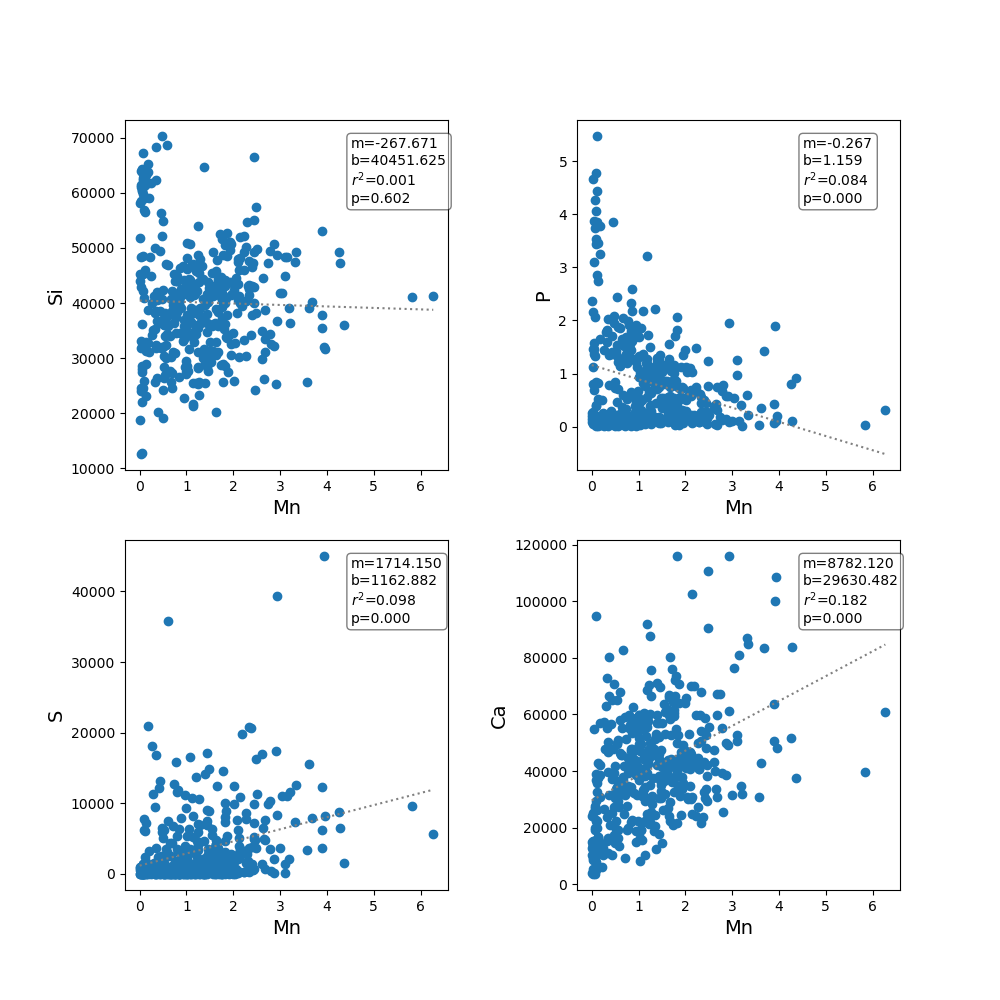

In [50]:
el_to_plot=4
nrows=2
ncols=int(el_to_plot/nrows)

fig,ax2d=plt.subplots(nrows,ncols)
fig.set_size_inches(10,10)
ax=np.ravel(ax2d)

fig.subplots_adjust(wspace=0.4)

props=dict(boxstyle='round',facecolor='white',alpha=0.5)

for count,el in enumerate(df_r2['name'][0:el_to_plot]):
    x='Mn'
    y=el
    ax[count].scatter(df[x],df[y])
    ax[count].set_xlabel(x,fontsize=14)
    ax[count].set_ylabel(y,fontsize=14)

    results=stats.linregress(df[[x,y]].dropna())

    textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)

    x_fit=np.array([df[x].min(),df[x].max()])
    ax[count].plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

    ax[count].text(0.7,0.95,textstr,transform=ax[count].transAxes,fontsize=10\
            ,verticalalignment='top',bbox=props)

filename=x+'_correlations.jpg'
fig.savefig(filename)

### 6 graphs with As

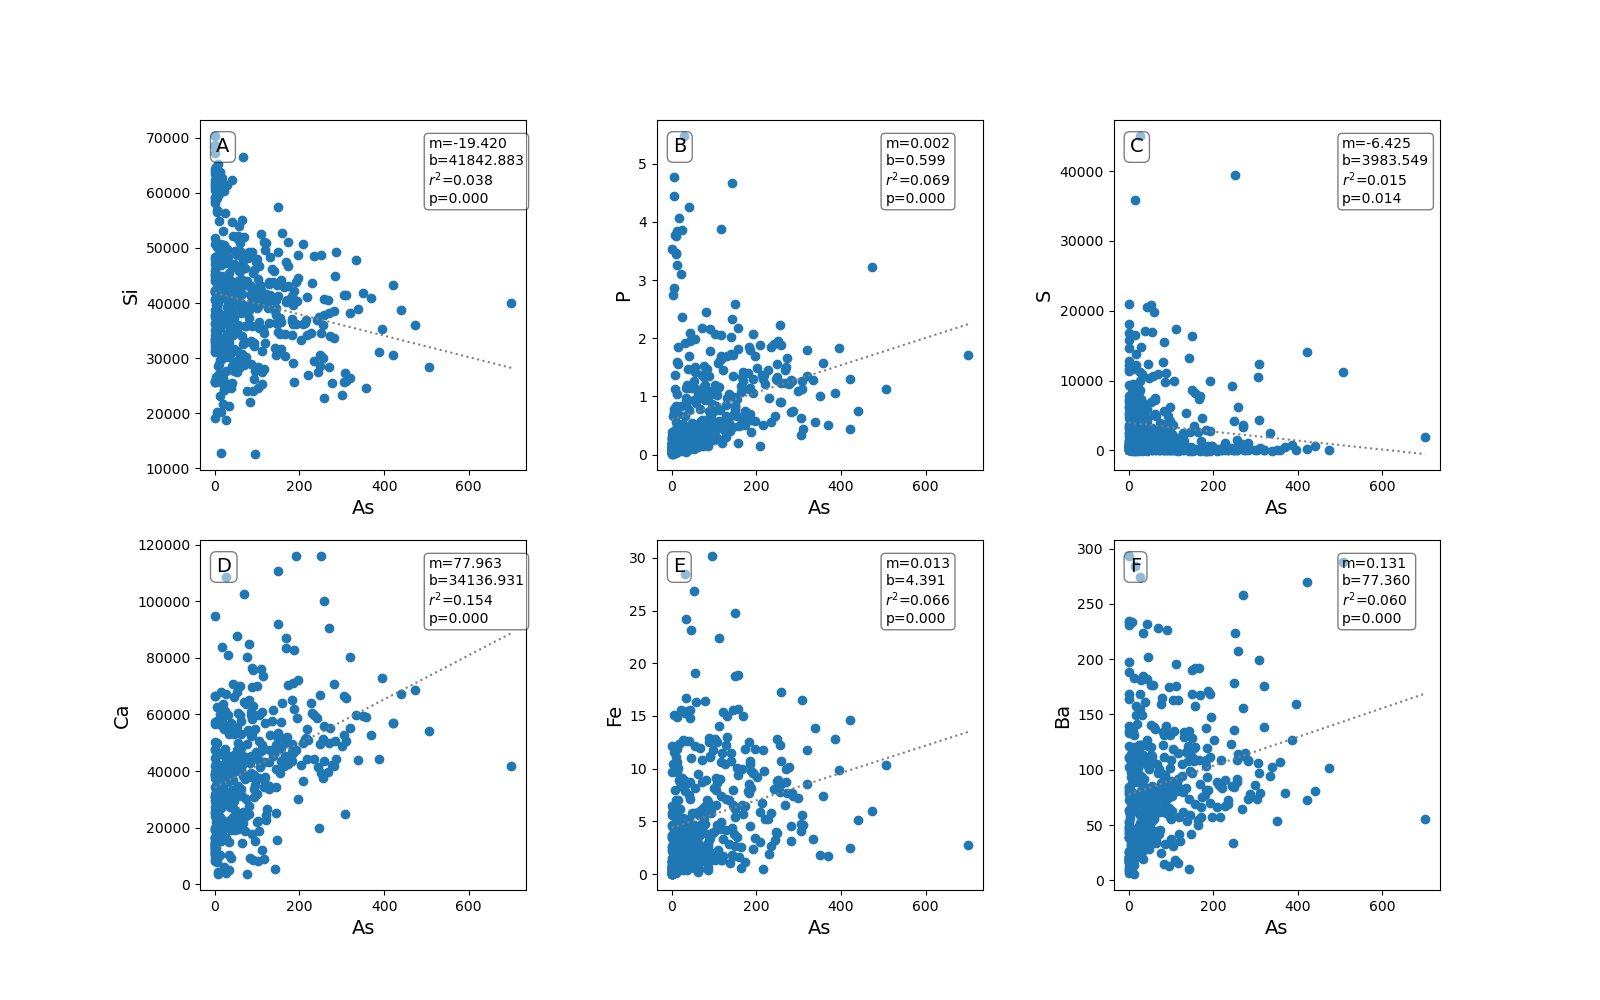

In [51]:
el_to_plot=6
nrows=2
ncols=int(el_to_plot/nrows)

fig,ax2d=plt.subplots(nrows,ncols)
fig.set_size_inches(16,10)
ax=np.ravel(ax2d)

fig.subplots_adjust(wspace=0.4)

props=dict(boxstyle='round',facecolor='white',alpha=0.5)

for count,el in enumerate(df_r2['name'][0:el_to_plot]):
    x='As'
    y=el
    ax[count].scatter(df[x],df[y])
    ax[count].set_xlabel(x,fontsize=14)
    ax[count].set_ylabel(y,fontsize=14)

    results=stats.linregress(df[[x,y]].dropna())

    textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'.\
                    format(results.slope,results.intercept\
                          ,results.rvalue**2,results.pvalue)

    x_fit=np.array([df[x].min(),df[x].max()])
    ax[count].plot(x_fit,results.slope*x_fit+results.intercept,color='gray',linestyle='dotted')

    ax[count].text(0.7,0.95,textstr,transform=ax[count].transAxes,fontsize=10\
            ,verticalalignment='top',bbox=props)
    ax[count].text(0.05,0.95,chr(count + ord('A')),transform=ax[count].transAxes\
                   ,fontsize=14,verticalalignment='top',bbox=props)

filename=x+'_correlations.jpg'
fig.savefig(filename)

